# 📈 Time Series Analysis and Forecasting

### Brazilian Automotive Production Index

This notebook presents a complete workflow for analyzing and forecasting the Brazilian Automotive Production Index using classical statistical time series techniques.

**Topics covered**

- Time Series Preparation
- Exploratory Time Series Visualization
- Time Series Decomposition
- Autoregressive (AR) Model
- Seasonal ARIMA Model
- Exponential Smoothing (SES & Holt)
- Forecast Comparison

---

# LIBRARIES AND FUNCTIONS

In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from datetime import datetime as dt
import pytz
import statsmodels.api as sm
import pytz
import json
import os
from statsmodels.tsa.api import acf, graphics, pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.api import qqplot
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_predict
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

In [2]:
def check_stationarity(ts):

    resultado_adf = adfuller(ts, autolag="AIC")

    print("Augmented Dickey-Fuller Test")
    print("-" * 35)
    print(f"ADF Statistic : {resultado_adf[0]:.2f}")
    print(f"p-value       : {resultado_adf[1]:.5f}")
    print(f"Lags Used     : {resultado_adf[2]}")
    print("\nCritical Values:")

    for key, value in resultado_adf[4].items():
        print(f"  {key}: {value:.2f}")

    if resultado_adf[1] < 0.05:
        print("\nConclusion: The series is stationary.")
    else:
        print("\nConclusion: The series is non-stationary.")

    return resultado_adf

In [3]:
def plot_time_series(ts, title=None, yLabel=None, xLabel=None, seriesLabel=None):

    resultados = check_stationarity(ts)

    if title is None:
        title = "Time Series"

    fig, ax = plt.subplots(figsize=(15, 6))

    ts.plot(
        ax=ax,
        label=seriesLabel if seriesLabel else ts.name
    )

    ax.axhline(
        ts.mean(),
        color="red",
        linestyle="--",
        label="Mean"
    )

    ax.set_title(
        f"{title}\nADF p-value = {resultados[1]:.5f} | Mean = {ts.mean():.2f}"
    )

    ax.set_xlabel(xLabel)
    ax.set_ylabel(yLabel)

    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def composition(ts):
  import statsmodels.api as sm

  # Realizar a decomposição da série temporal
  decomposition = sm.tsa.seasonal_decompose(ts, model='additive')

  # Obter os componentes da decomposição
  trend = decomposition.trend
  seasonal = decomposition.seasonal
  residual = decomposition.resid

  # Plotar os componentes
  fig, ax = plt.subplots(figsize=(15, 8))
  ax.plot(ts.index, ts, label='Original')
  ax.plot(trend.index, trend, label='Trend')
  ax.plot(seasonal.index, seasonal, label='Seasonality')
  ax.plot(residual.index, residual, label='Residuals')
  ax.legend(loc='best')
  ax.set_title('Time Series Decomposition')
  ax.set_xlabel('Date')
  ax.set_ylabel('Production')
  plt.show()

#TIME SERIES ANALYSIS

## Data Source

This study uses the **Brazilian Automotive Production Index**, a monthly time series published by the National Association of Motor Vehicle Manufacturers (ANFAVEA) and made available through the Central Bank of Brazil (BCB) time series API.

In [5]:
# Load the Brazilian automotive production time series
path = "http://api.bcb.gov.br/dados/serie/bcdata.sgs.1373/dados?formato=csv"

production = pd.read_table(
    path,
    sep=";"
)

production

,data,valor
0,01/02/1993,73042
1,01/03/1993,98691
2,01/04/1993,88839
3,01/05/1993,101055
4,01/06/1993,102512
...,...,...
394,01/12/2025,184474
395,01/01/2026,163606
396,01/02/2026,206945
397,01/03/2026,263575


Dataset description: This monthly time series represents the Brazilian Automotive Production Index published by the National Association of Motor Vehicle Manufacturers (ANFAVEA) and distributed through the Central Bank of Brazil (BCB) API. Rather than measuring only the number of vehicles manufactured, the indicator reflects the overall performance of the Brazilian automotive industry by incorporating information related to vehicle production, inventories, dealership sales, vehicle commercialization, and motorcycle production.

## Time Series Preparation

The first step consists of preparing the time series for analysis by ensuring that it is regular and complete. This includes converting the index to a DateTimeIndex, enforcing a monthly frequency, removing duplicate observations when necessary, and filling any missing monthly records.

In [6]:
# Check for duplicated dates
print(f"Duplicated dates: {production.index.duplicated().sum()}")

# Check for duplicated values
print(f"Duplicated rows: {production.duplicated().sum()}")

# Check missing values
print(production.isna().sum())

Duplicated dates: 0
Duplicated rows: 0
data     0
valor    0
dtype: int64


In [7]:
# ETL: Regularize the time series
production.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   data    399 non-null    object
 1   valor   399 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ KB


In [8]:
# Convert the date column to datetime format
production["data"] = pd.to_datetime(production["data"], format='%d/%m/%Y')

# Set the date column as the index
production = production.set_index("data")

production

,valor
data,
1993-02-01,73042
1993-03-01,98691
1993-04-01,88839
1993-05-01,101055
1993-06-01,102512
...,...
2025-12-01,184474
2026-01-01,163606
2026-02-01,206945


In [9]:
# Convert the series to a regular monthly time series
production = production.asfreq('MS')

In [10]:
# Validate the resulting series
production.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 399 entries, 1993-02-01 to 2026-04-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   valor   399 non-null    int64
dtypes: int64(1)
memory usage: 6.2 KB


## Exploratory Time Series Visualization

Augmented Dickey-Fuller Test
-----------------------------------
ADF Statistic : -1.91
p-value       : 0.32558
Lags Used     : 13

Critical Values:
  1%: -3.45
  5%: -2.87
  10%: -2.57

Conclusion: The series is non-stationary.


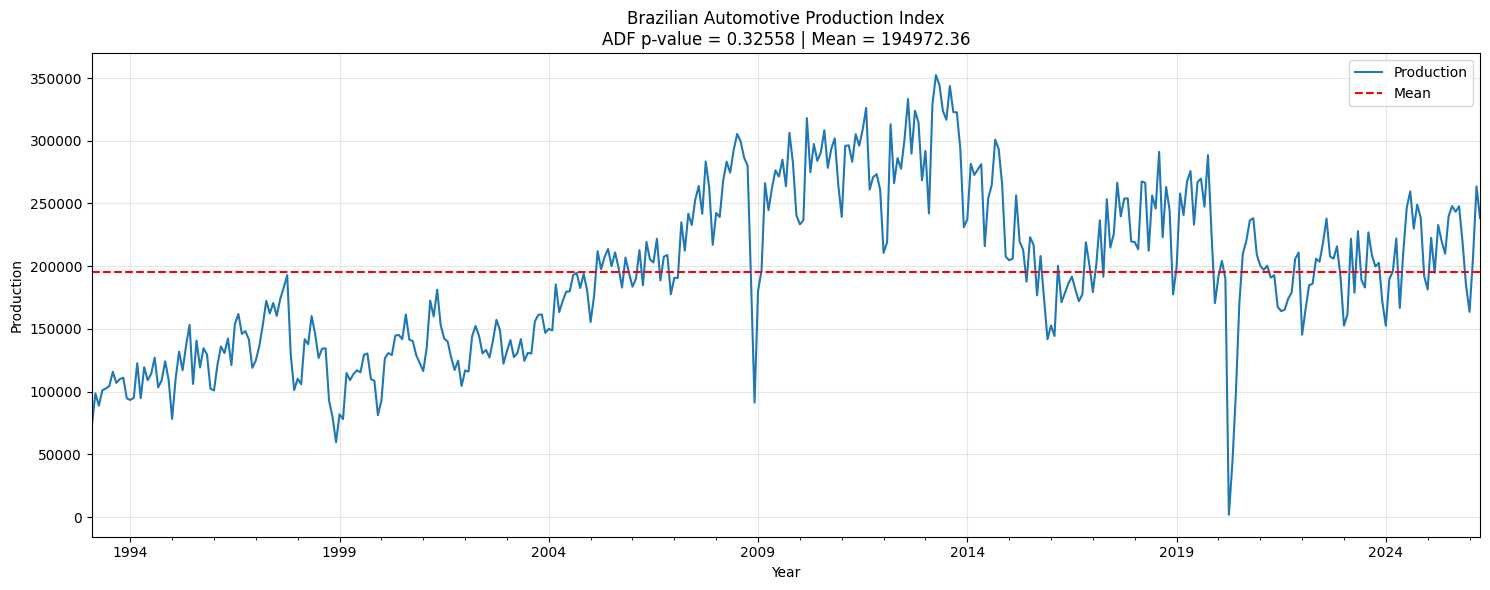

In [11]:
# Plot the complete time series and perform an Augmented Dickey-Fuller test
plot_time_series(
    production["valor"],
    title="Brazilian Automotive Production Index",
    xLabel="Year",
    yLabel="Production",
    seriesLabel="Production"
)

## Time Series Decomposition

Decompose the original time series into its trend, seasonal, and residual components to better understand the underlying temporal patterns.

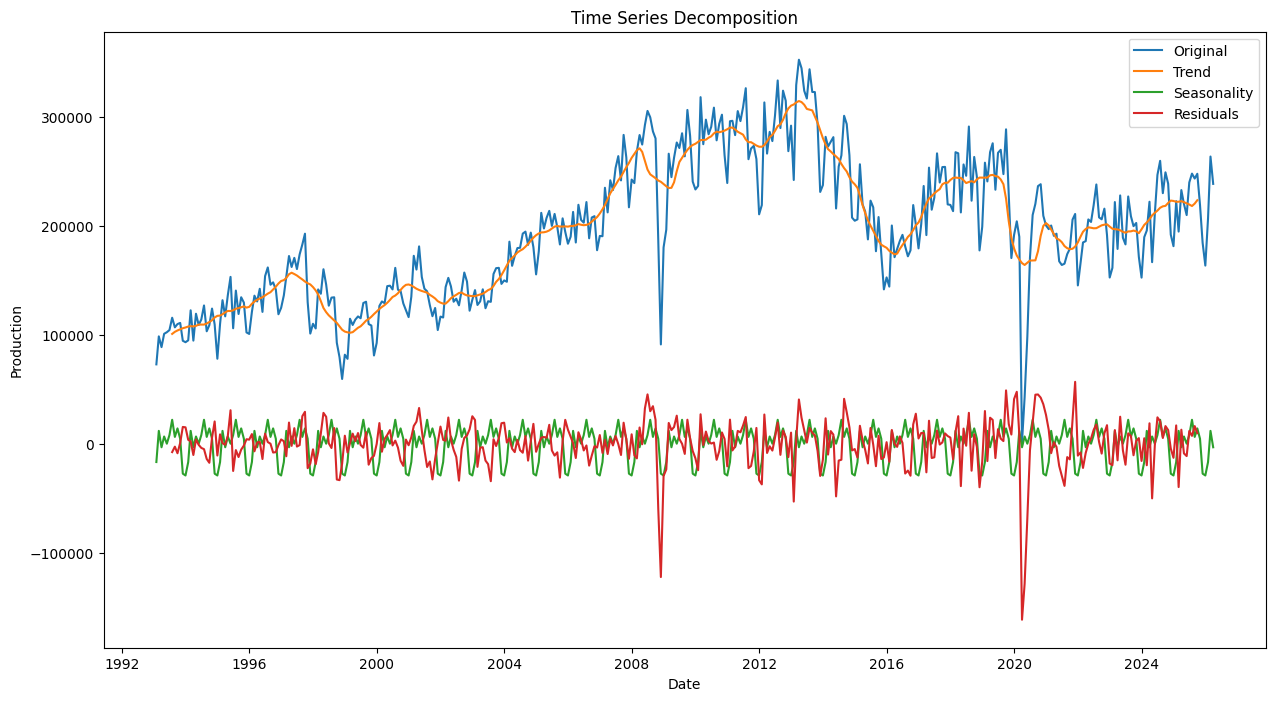

In [12]:
composition(production)

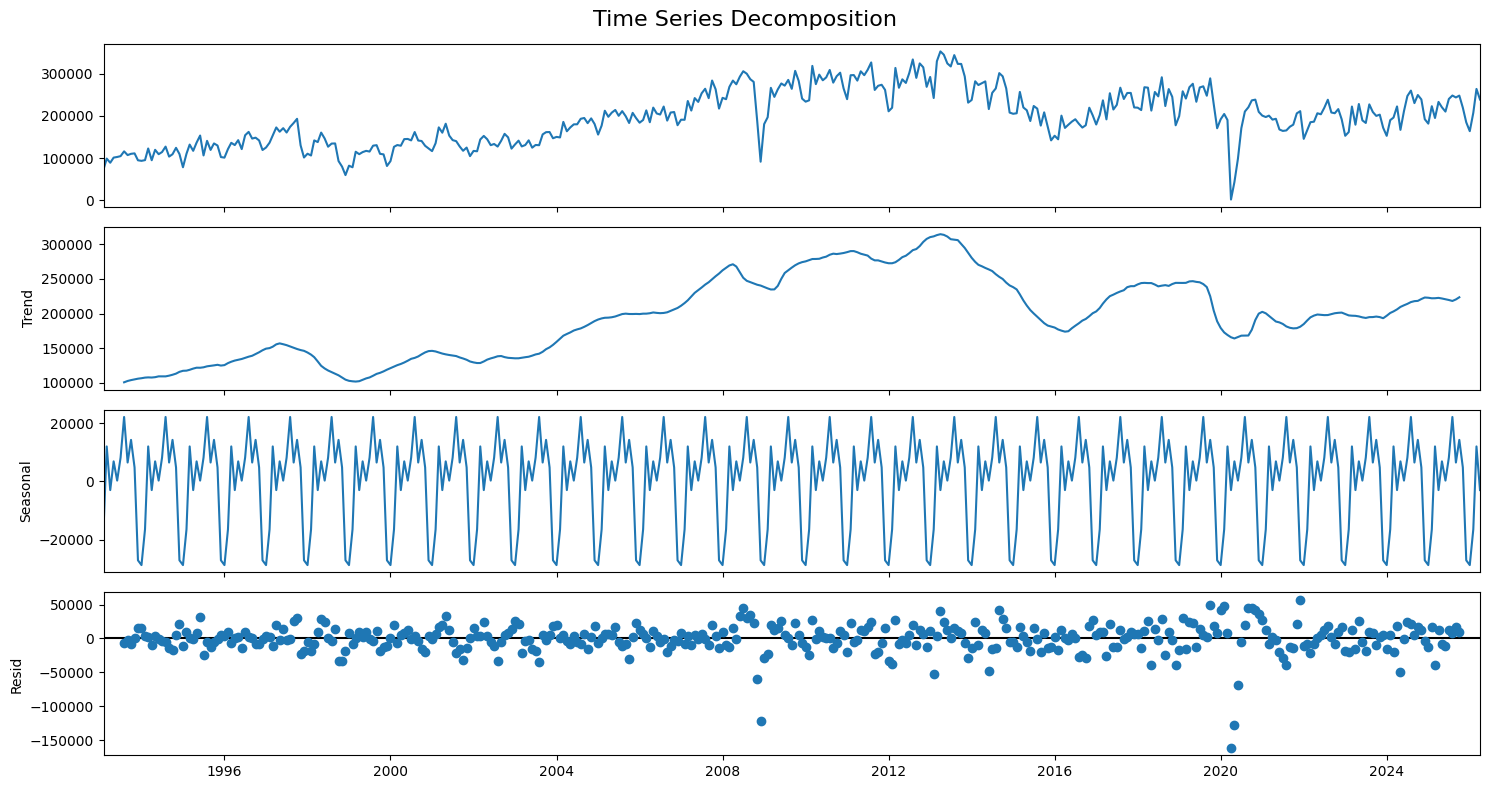

In [13]:
# Plot the decomposed time series components
decomposition = sm.tsa.seasonal_decompose(production, model="additive")

fig = decomposition.plot()
fig.set_size_inches(15, 8)
fig.suptitle("Time Series Decomposition", fontsize=16)

plt.tight_layout()
plt.show()

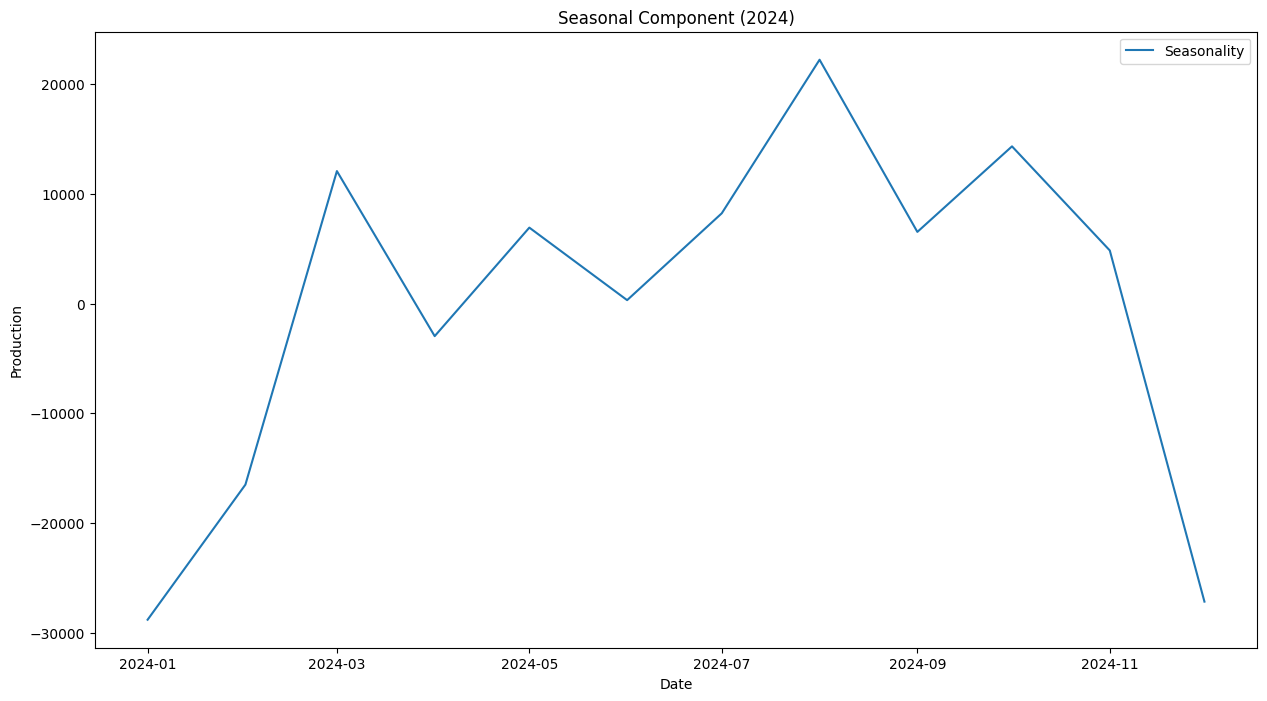

In [14]:
# Zoom in on the seasonal component
seasonal = decomposition.seasonal

fig, ax = plt.subplots(figsize=(15, 8))

year = "2024"

ax.plot(
    seasonal.loc[year].index,
    seasonal.loc[year],
    label="Seasonality"
)

ax.set_title(f"Seasonal Component ({year})")

ax.legend(loc="best")
ax.set_title(f"Seasonal Component ({year})")
ax.set_xlabel("Date")
ax.set_ylabel("Production")

plt.show()

**Comments on the Decomposition Analysis**

1. **Overall Series:** The time series exhibits a clear long-term upward trend combined with pronounced seasonal fluctuations, indicating a strong annual seasonal pattern. The series also presents considerable volatility, with several abrupt declines. These sharp drops are likely associated with major economic events, such as the 2008 global financial crisis, the Brazilian economic recession of 2015–2016, and the COVID-19 pandemic in 2020.

2. **Trend Component:** The trend is non-linear and characterized by alternating periods of expansion and contraction rather than continuous growth. This behavior suggests that the automotive sector is influenced by medium- and long-term economic cycles.

3. **Seasonal Component:** A strong and consistent annual seasonal pattern is observed throughout the entire series. The relatively stable seasonal amplitude indicates that seasonality is an important characteristic of the data and should be incorporated into the forecasting models.

4. **Residual Component:** The residuals are generally centered around zero, indicating that the trend and seasonal components capture most of the systematic variation in the series. However, several large negative residuals are present, corresponding to extraordinary events not explained by the decomposition model. The residual variance appears to change over time, suggesting possible heteroscedasticity.


# AUTOREGRESSIVE (AR) MODEL

## Model Training

In [15]:
# Train an autoregressive model with 12 lags
ar_model = AutoReg(production["valor"], lags=12)
ar_results = ar_model.fit(cov_type="HC0")

## Statistical Model Summary

In [16]:
# Display the autoregressive model summary
print(ar_results.summary())

                            AutoReg Model Results                             
Dep. Variable:                  valor   No. Observations:                  399
Model:                    AutoReg(12)   Log Likelihood               -4490.570
Method:               Conditional MLE   S.D. of innovations          26492.096
Date:                Thu, 25 Jun 2026   AIC                           9009.140
Time:                        13:59:14   BIC                           9064.558
Sample:                    02-01-1994   HQIC                          9031.115
                         - 04-01-2026                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       9328.9950   3877.786      2.406      0.016    1728.673    1.69e+04
valor.L1       0.6362      0.067      9.493      0.000       0.505       0.768
valor.L2       0.0293      0.066      0.442      0.6

Model Interpretation

The AutoReg(12) model identifies a strong temporal dependence in the series. The first lag (Lag 1) is highly significant (p < 0.01), indicating that the current production level is strongly influenced by the previous month's observation. Additionally, the twelfth lag (Lag 12) is also statistically significant (p < 0.01), confirming the presence of an annual seasonal pattern previously identified during the decomposition analysis.

Although the model captures the main temporal dynamics, most intermediate lags (L2–L4 and L6–L11) are not statistically significant. This suggests that these additional parameters contribute little to explaining the series and may unnecessarily increase model complexity.

Finally, all characteristic roots have a modulus greater than one, indicating that the fitted autoregressive process satisfies the stationarity condition.

## Residual Diagnostics



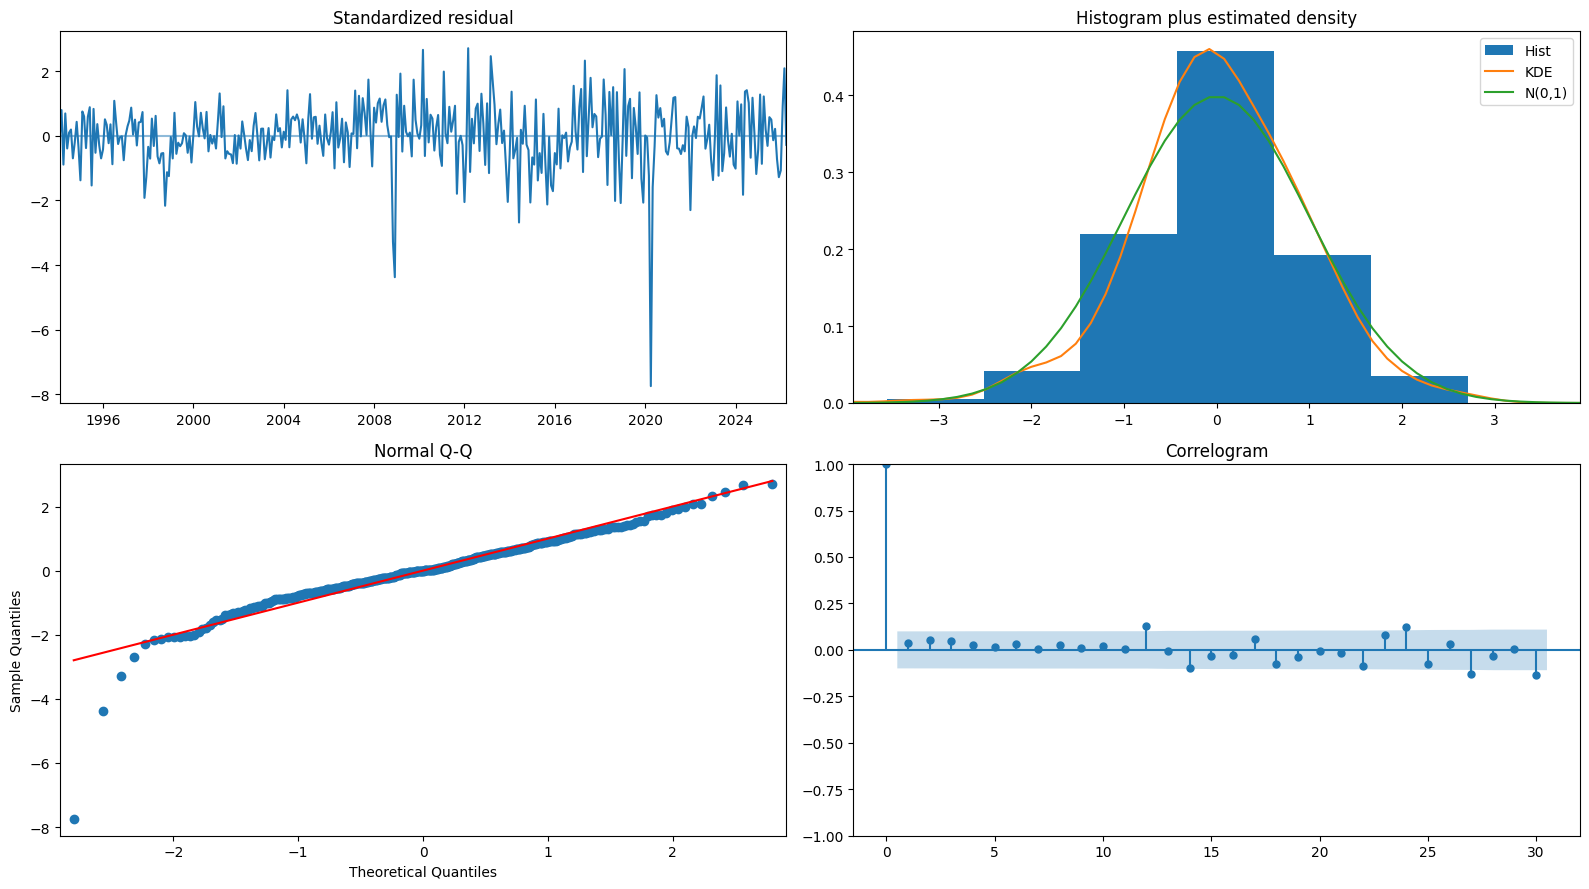

In [17]:
# Plot diagnostic charts for the autoregressive model
fig = plt.figure(figsize=(16, 9))
fig = ar_results.plot_diagnostics(fig=fig, lags=30)

plt.tight_layout()
plt.show()

Residual Diagnostics Interpretation

The residual diagnostics indicate that the autoregressive model adequately captures the temporal correlation structure of the data. The correlogram shows that most residual autocorrelations remain within the confidence bounds, suggesting that little serial dependence remains after model fitting. The histogram and Q–Q plot indicate an approximately normal distribution of the residuals, although deviations in the tails reveal the presence of extreme observations, primarily associated with external events such as the COVID-19 pandemic in 2020.

## Three-Month Forecast

In [18]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="This axis already has a converter set.*"
)

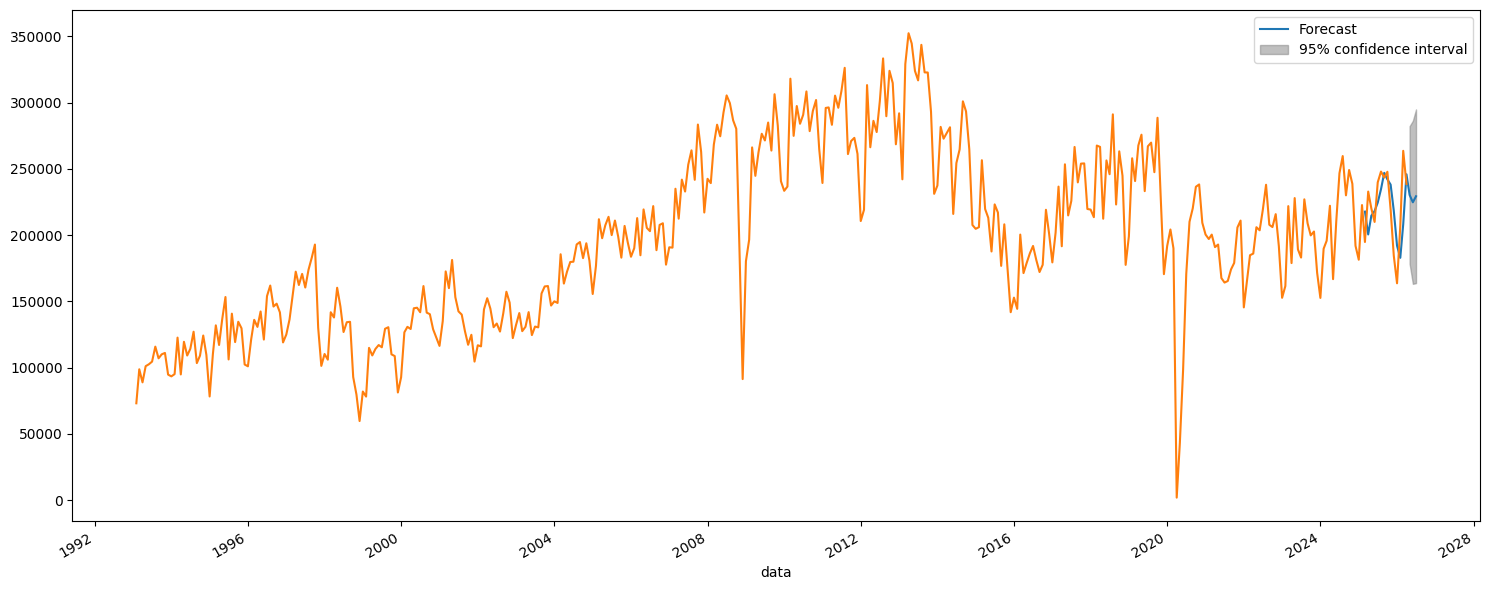

In [19]:
# Forecast settings
forecast_horizon = 3
history_window = 14

# Total number of observations
n = len(production)

# Plot the forecast for the next three months
fig = ar_results.plot_predict(
    start=n - history_window,
    end=n + forecast_horizon - 1
)

# Get the axis object
ax = fig.axes[0]

# Overlay the original time series
production["valor"].plot(
    ax=ax,
    figsize=(15, 6)
)

plt.tight_layout()
plt.show()

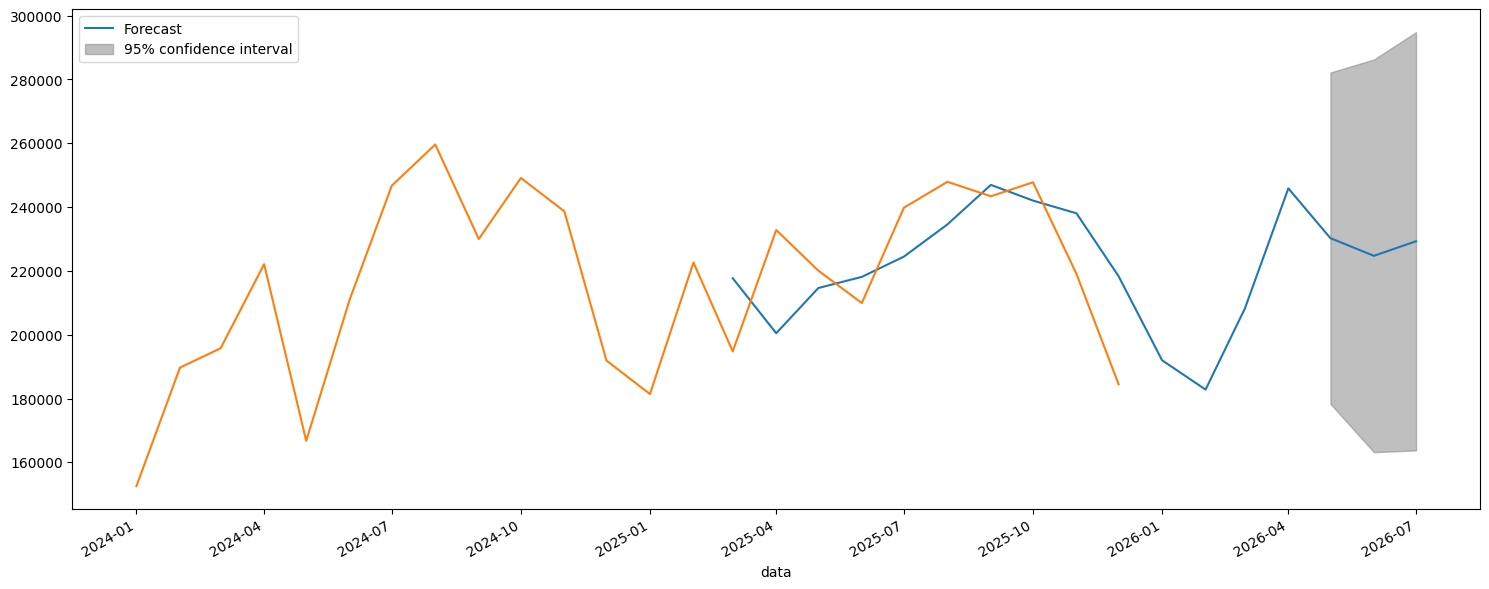

In [20]:
# Forecast settings
forecast_horizon = 3
history_window = 14

# Total number of observations
n = len(production)

# Zoom in on the forecast period
fig = ar_results.plot_predict(
    start=n - history_window,
    end=n + forecast_horizon - 1
)

ax = fig.axes[0]

production.loc["2024":"2025", "valor"].plot(
    ax=ax,
    figsize=(15, 6)
)

plt.tight_layout()
plt.show()

# SEASONAL ARIMA MODEL

## Model Training

In [21]:
# Train a seasonal ARIMA model
arima_model = ARIMA(
    production["valor"],
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 12)
)

arima_results = arima_model.fit()

## Statistical Model Summary

In [22]:
# Display the ARIMA model summary
print(arima_results.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            valor   No. Observations:                  399
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood               -4481.618
Date:                          Thu, 25 Jun 2026   AIC                           8971.235
Time:                                  13:59:22   BIC                           8987.059
Sample:                              02-01-1993   HQIC                          8977.510
                                   - 04-01-2026                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4869      0.122      4.005      0.000       0.249       0.725
ma.L1         -0.7902      0.097     -8.117      0.

**Model Interpretation**

The seasonal ARIMA(1,1,1)(0,1,1,12) model provides a good representation of the time series dynamics. All estimated parameters are statistically significant (p < 0.05), indicating that each component contributes meaningfully to the model. The significant seasonal moving average term (MA(12)) confirms the presence of a strong annual seasonal pattern, consistent with the decomposition analysis. Although the estimated innovation variance (σ²) remains relatively high, reflecting the inherent variability of the series, the Ljung–Box test (p > 0.05) indicates that no significant autocorrelation remains in the residuals, suggesting that the model adequately captures the temporal dependence of the data.

## Residual Diagnostics

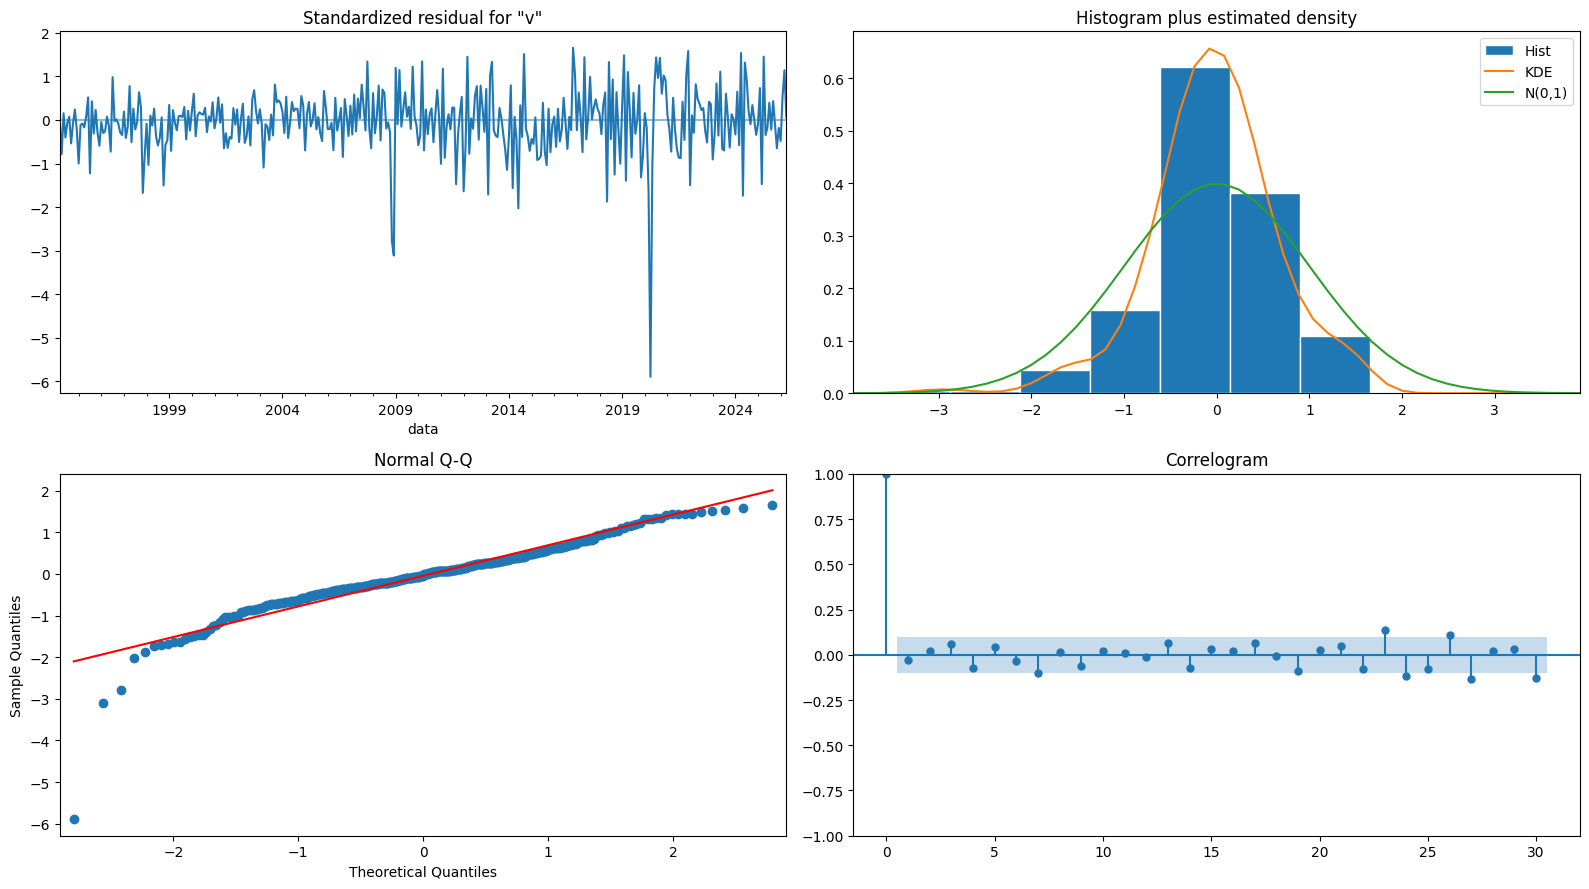

In [23]:
# Plot diagnostic charts for the ARIMA model
fig = plt.figure(figsize=(16, 9))

arima_results.plot_diagnostics(
    fig=fig,
    lags=30
)

fig.tight_layout()
plt.show()

Residual Diagnostics Interpretation

The residual diagnostics indicate that the seasonal ARIMA model provides a good representation of the time series dynamics. The standardized residuals fluctuate around zero without any evident systematic pattern, although a few large negative residuals remain, corresponding to extraordinary events such as the COVID-19 pandemic.

The histogram and Q–Q plot suggest that the residuals are approximately normally distributed. Most observations closely follow the theoretical normal distribution, while deviations in the distribution tails indicate the presence of extreme observations and slightly heavier tails than expected under perfect normality.

The correlogram shows that nearly all residual autocorrelations remain within the confidence bounds, indicating that the residuals behave similarly to white noise. Overall, the seasonal ARIMA model produces cleaner residuals than the autoregressive model, suggesting a better representation of both the temporal and seasonal structure of the series.

## Three-Month Forecast

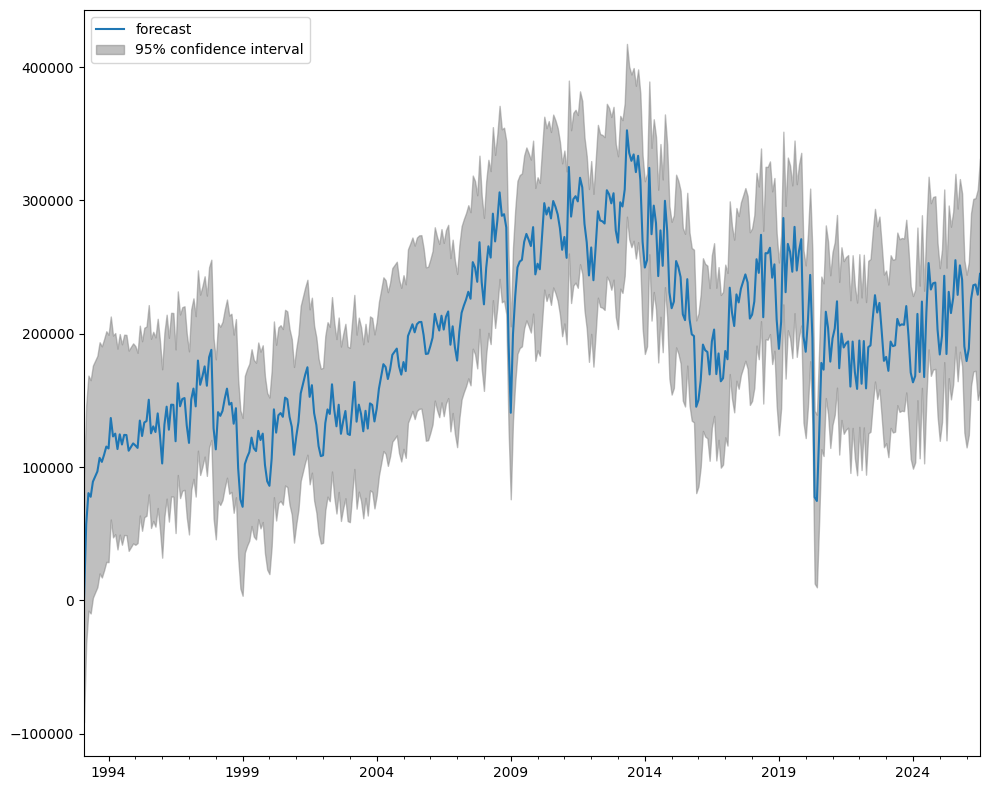

In [24]:
# Forecast settings
forecast_horizon = 3
zoom_months = 36

# Time range
start_date = production.index.min()
end_date = production.index.max() + pd.DateOffset(months=forecast_horizon)

# Plot the three-month forecast over the complete time series
fig, ax = plt.subplots(figsize=(10, 8))

plot_predict(
    arima_results,
    start=start_date,
    end=end_date,
    ax=ax
)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

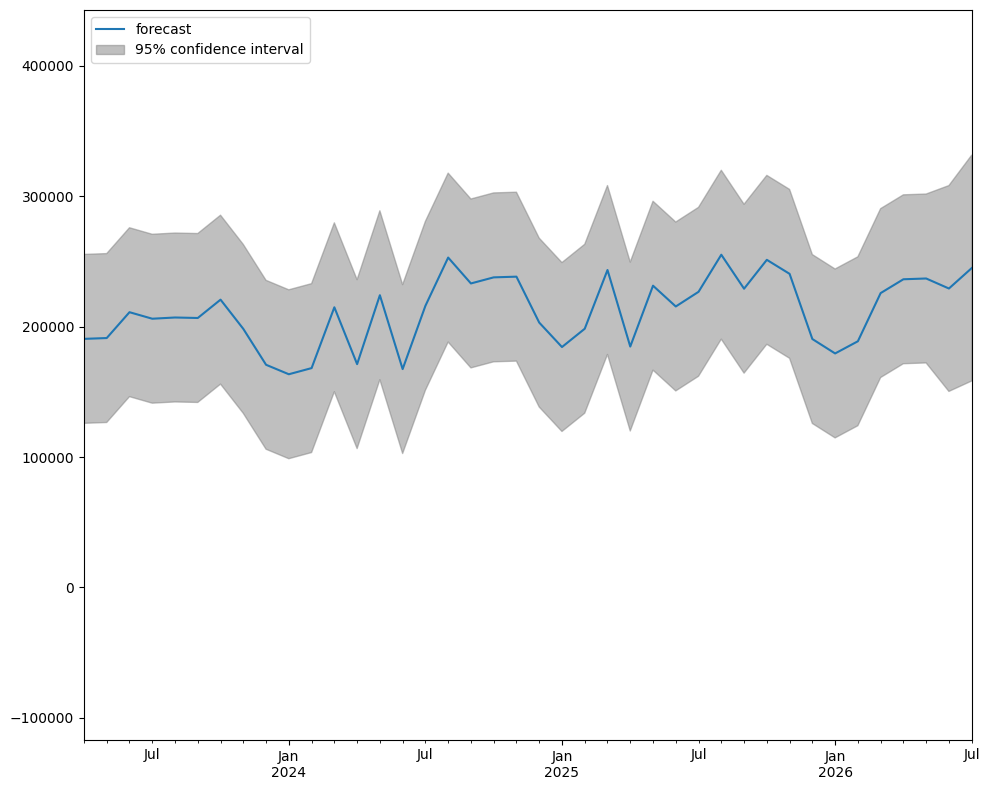

In [25]:
# Forecast settings
forecast_horizon = 3
zoom_months = 36

# Time range
start_date = production.index.min()
end_date = production.index.max() + pd.DateOffset(months=forecast_horizon)

# Zoom start date
zoom_start = production.index.max() - pd.DateOffset(months=zoom_months)

# Zoom in on the forecast period
fig, ax = plt.subplots(figsize=(10, 8))

plot_predict(
    arima_results,
    start=start_date,
    end=end_date,
    ax=ax
)

ax.set_xlim(zoom_start, end_date)

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Model Comparison**

The time series exhibits a pronounced seasonal pattern, making it difficult for the autoregressive (AR) model to capture all of its temporal dynamics. Nevertheless, despite its relatively simple structure, the AR model provides a reasonable representation of the data and is able to identify the overall trend, including the recurring decline observed toward the end of each year.

The decomposition analysis indicated from the outset that the series contained a strong annual seasonal component, suggesting that a seasonal ARIMA model would be more appropriate. After incorporating both regular and seasonal differencing, together with autoregressive and moving average components, the seasonal ARIMA model captured the underlying temporal and seasonal structure more effectively than the autoregressive model.

This improvement is reflected in the residual diagnostics, which show weaker residual autocorrelation, a distribution closer to normality, and a better overall representation of the observed time series.


# EXPONENTIAL SMOOTHING METHODS

In [26]:
# Forecast settings
forecast_horizon = 3
history_window = 22

# Use the most recent observations
series = production.iloc[-history_window:]

## Simple Exponential Smoothing (SES)

In [27]:
# Train Simple Exponential Smoothing models

fit1 = SimpleExpSmoothing(
    series,
    initialization_method="heuristic"
).fit(
    smoothing_level=0.2,
    optimized=False
)

fit2 = SimpleExpSmoothing(
    series,
    initialization_method="heuristic"
).fit(
    smoothing_level=0.6,
    optimized=False
)

fit3 = SimpleExpSmoothing(
    series,
    initialization_method="estimated"
).fit()

In [28]:
forecast1 = fit1.forecast(forecast_horizon).rename("SES (α = 0.20)")

forecast2 = fit2.forecast(forecast_horizon).rename("SES (α = 0.60)")

forecast3 = fit3.forecast(forecast_horizon).rename(
    f"SES (Optimized α = {fit3.model.params['smoothing_level']:.3f})"
)

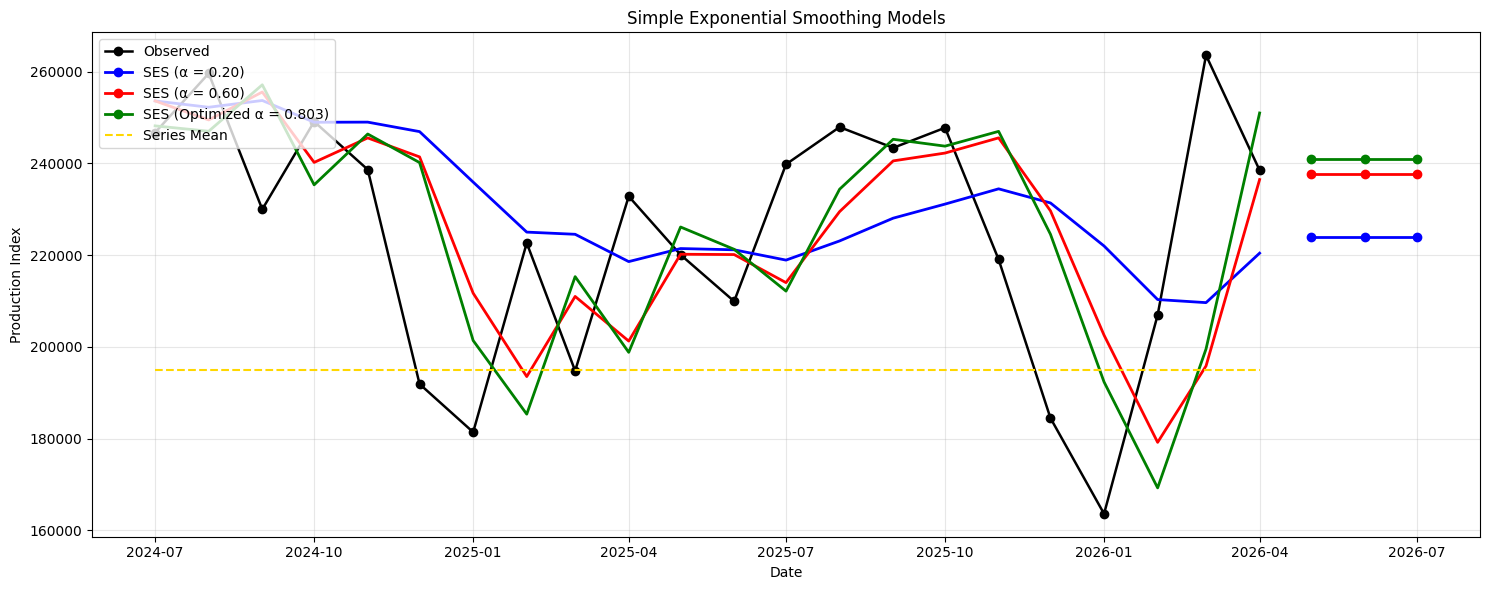

In [29]:
# Plot the Simple Exponential Smoothing models
plt.figure(figsize=(15, 6))

# Observed series
(observed_line,) = plt.plot(
    series,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Observed"
)

# SES (α = 0.20)
plt.plot(fit1.fittedvalues, color="blue", linewidth=2)
(forecast1_line,) = plt.plot(
    forecast1,
    color="blue",
    marker="o",
    linewidth=2,
    label="SES (α = 0.20)"
)

# SES (α = 0.60)
plt.plot(fit2.fittedvalues, color="red", linewidth=2)
(forecast2_line,) = plt.plot(
    forecast2,
    color="red",
    marker="o",
    linewidth=2,
    label="SES (α = 0.60)"
)

# Optimized SES
plt.plot(fit3.fittedvalues, color="green", linewidth=2)
(forecast3_line,) = plt.plot(
    forecast3,
    color="green",
    marker="o",
    linewidth=2,
    label=f"SES (Optimized α = {fit3.model.params['smoothing_level']:.3f})"
)

# Series mean
(mean_line,) = plt.plot(
    [series.index[0], series.index[-1]],
    [production["valor"].mean(), production["valor"].mean()],
    color="gold",
    linestyle="--",
    linewidth=1.5,
    label="Series Mean"
)

plt.title("Simple Exponential Smoothing Models")
plt.xlabel("Date")
plt.ylabel("Production Index")

plt.grid(alpha=0.3)

plt.legend(
    handles=[
        observed_line,
        forecast1_line,
        forecast2_line,
        forecast3_line,
        mean_line
    ],
    loc="upper left"
)

plt.tight_layout()
plt.show()

**Simple Exponential Smoothing Interpretation**

The smoothing parameter controls how strongly recent observations influence the forecasts. Lower smoothing levels produce smoother predictions by emphasizing historical values, whereas higher levels respond more quickly to recent changes. The optimized smoothing parameter automatically balances stability and responsiveness based on the observed data.

In [30]:
forecast_df = pd.DataFrame({
    "SES (α = 0.20)": forecast1,
    "SES (α = 0.60)": forecast2,
    f"SES (Optimized α = {fit3.model.params['smoothing_level']:.3f})": forecast3
})

forecast_df

,SES (α = 0.20),SES (α = 0.60),SES (Optimized α = 0.803)
2026-05-01,224042.816768,237691.230902,240953.04155
2026-06-01,224042.816768,237691.230902,240953.04155
2026-07-01,224042.816768,237691.230902,240953.04155


## Holt's Exponential Smoothing Models

In [31]:
# Train Holt's trend models
holt_linear = Holt(
    series,
    initialization_method="estimated"
).fit(
    smoothing_level=0.8,
    smoothing_trend=0.2,
    optimized=False
)

forecast_linear = holt_linear.forecast(forecast_horizon).rename("Linear Trend")

holt_exponential = Holt(
    series,
    exponential=True,
    initialization_method="estimated"
).fit(
    smoothing_level=0.8,
    smoothing_trend=0.2,
    optimized=False
)

forecast_exponential = holt_exponential.forecast(forecast_horizon).rename(
    "Exponential Trend"
)

holt_damped = Holt(
    series,
    damped_trend=True,
    initialization_method="estimated"
).fit(
    smoothing_level=0.8,
    smoothing_trend=0.2
)

forecast_damped = holt_damped.forecast(forecast_horizon).rename(
    "Damped Trend"
)

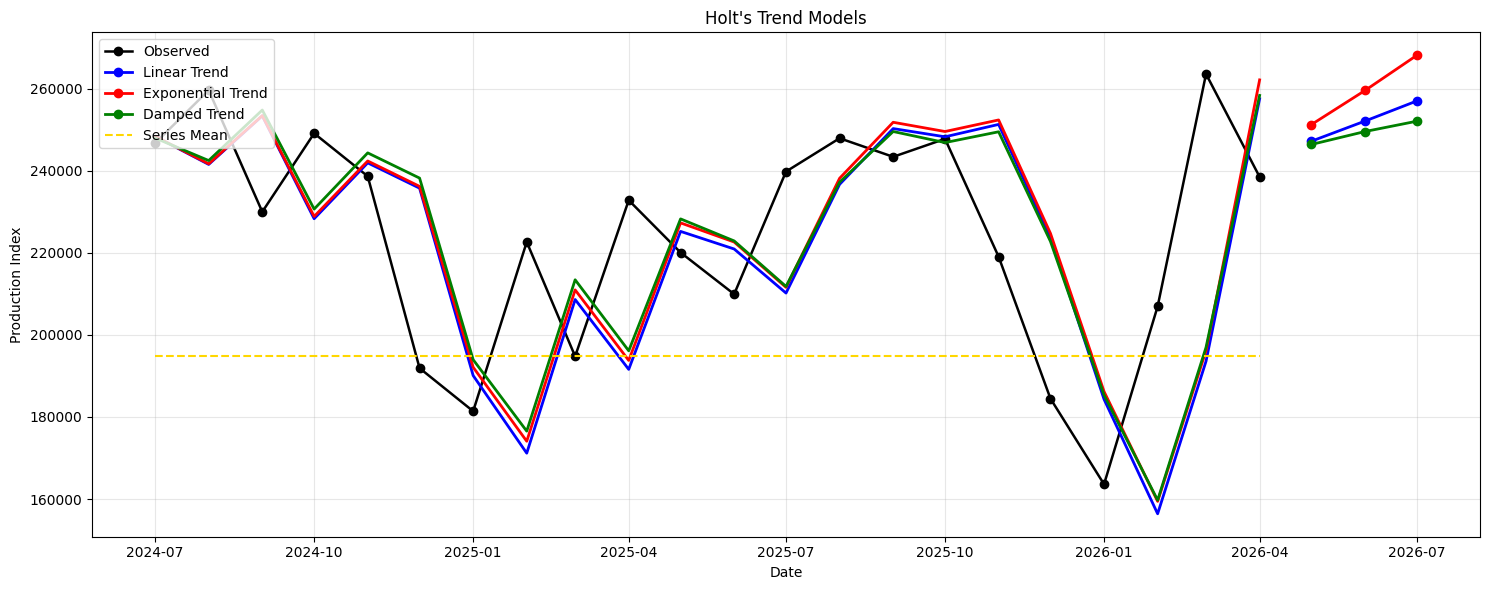

In [32]:
# Plot Holt's trend models
plt.figure(figsize=(15, 6))

# Observed series
(observed_line,) = plt.plot(
    series,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Observed"
)

# Linear trend
plt.plot(holt_linear.fittedvalues, color="blue", linewidth=2)
(linear_line,) = plt.plot(
    forecast_linear,
    color="blue",
    marker="o",
    linewidth=2,
    label=forecast_linear.name
)

# Exponential trend
plt.plot(holt_exponential.fittedvalues, color="red", linewidth=2)
(exponential_line,) = plt.plot(
    forecast_exponential,
    color="red",
    marker="o",
    linewidth=2,
    label=forecast_exponential.name
)

# Damped trend
plt.plot(holt_damped.fittedvalues, color="green", linewidth=2)
(damped_line,) = plt.plot(
    forecast_damped,
    color="green",
    marker="o",
    linewidth=2,
    label=forecast_damped.name
)

# Series mean
(mean_line,) = plt.plot(
    [series.index[0], series.index[-1]],
    [production["valor"].mean(), production["valor"].mean()],
    color="gold",
    linestyle="--",
    linewidth=1.5,
    label="Series Mean"
)

plt.title("Holt's Trend Models")
plt.xlabel("Date")
plt.ylabel("Production Index")

plt.grid(alpha=0.3)

plt.legend(
    handles=[
        observed_line,
        linear_line,
        exponential_line,
        damped_line,
        mean_line
    ],
    loc="upper left"
)

plt.tight_layout()
plt.show()

Holt's Method Interpretation

Holt's linear trend extends simple exponential smoothing by incorporating a trend component into the forecasting process. Compared with the simple exponential smoothing model, it responds more effectively to sustained increases or decreases in the series while maintaining smooth short-term forecasts.

In [33]:
# Create a DataFrame to compare the forecasts
holt_forecasts = pd.DataFrame({
    "Linear Holt": forecast_linear,
    "Exponential Holt": forecast_exponential,
    "Damped Holt": forecast_damped
})

# Display the forecast comparison
holt_forecasts

,Linear Holt,Exponential Holt,Damped Holt
2026-05-01,247206.405558,251262.259172,246406.624554
2026-06-01,252109.448885,259563.821141,249556.788466
2026-07-01,257012.492213,268139.661990,252076.919596


## Forecast Comparison

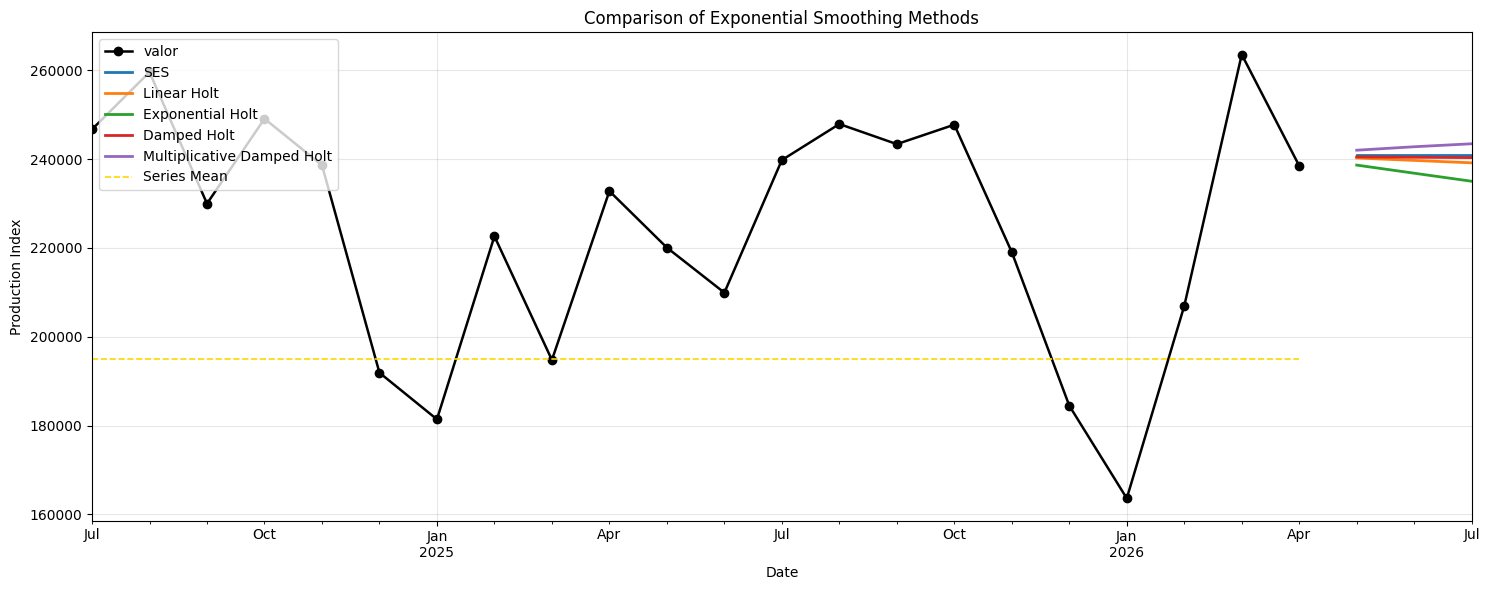

In [34]:
# Compare exponential smoothing forecasting methods

# Use the most recent observations
series = production.iloc[-history_window:]

# Train the forecasting models

# Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(
    series,
    initialization_method="estimated"
).fit()

forecast_ses = ses_model.forecast(forecast_horizon).rename("SES")

# Holt's Linear Trend
holt_linear = Holt(
    series,
    initialization_method="estimated"
).fit()

forecast_linear = holt_linear.forecast(forecast_horizon).rename("Linear Holt")

# Holt's Exponential Trend
holt_exponential = Holt(
    series,
    exponential=True,
    initialization_method="estimated"
).fit()

forecast_exponential = holt_exponential.forecast(
    forecast_horizon
).rename("Exponential Holt")

# Holt's Damped Trend
holt_damped = Holt(
    series,
    damped_trend=True,
    initialization_method="estimated"
).fit()

forecast_damped = holt_damped.forecast(
    forecast_horizon
).rename("Damped Holt")

# Holt's Multiplicative Damped Trend
holt_multiplicative = Holt(
    series,
    exponential=True,
    damped_trend=True,
    initialization_method="estimated"
).fit()

forecast_multiplicative = holt_multiplicative.forecast(
    forecast_horizon
).rename("Multiplicative Damped Holt")

# Plot the forecast comparison

fig, ax = plt.subplots(figsize=(15, 6))

# Observed series
series.plot(
    ax=ax,
    color="black",
    marker="o",
    linewidth=1.8,
    label="Observed"
)

# Forecasts
forecast_ses.plot(
    ax=ax,
    linewidth=2,
    label=forecast_ses.name
)

forecast_linear.plot(
    ax=ax,
    linewidth=2,
    label=forecast_linear.name
)

forecast_exponential.plot(
    ax=ax,
    linewidth=2,
    label=forecast_exponential.name
)

forecast_damped.plot(
    ax=ax,
    linewidth=2,
    label=forecast_damped.name
)

forecast_multiplicative.plot(
    ax=ax,
    linewidth=2,
    label=forecast_multiplicative.name
)

# Mean of the complete series
ax.hlines(
    production["valor"].mean(),
    series.index[0],
    series.index[-1],
    colors="gold",
    linestyles="--",
    linewidth=1.2,
    label="Series Mean"
)

# Formatting
ax.set_title("Comparison of Exponential Smoothing Methods")
ax.set_xlabel("Date")
ax.set_ylabel("Production Index")

ax.grid(alpha=0.3)

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**Comparison of Holt's Models**

Holt's forecasting methods produce similar short-term predictions, with differences primarily related to the treatment of the trend component. The exponential and multiplicative damped models project slightly stronger growth, whereas the damped trend generates more conservative forecasts by gradually reducing the trend over time. Since the forecast horizon is limited to three months, all variants provide comparable results.

**Comparison of Exponential Smoothing Models**

The exponential smoothing methods produce very similar forecasts over the three-month prediction horizon, indicating that the recent observations dominate the short-term projections. The differences become more apparent in how each model extrapolates the trend, with the exponential and multiplicative variants producing slightly stronger growth, while the damped model yields more conservative forecasts. Given the pronounced annual seasonality identified earlier, these methods provide reasonable short-term forecasts but do not explicitly model the seasonal component, making the seasonal ARIMA model the most appropriate approach for this dataset.